In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('housing_price_prediction.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.shape

(545, 13)

Total 545 rows with 13 columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

no null values

In [7]:
df.duplicated().sum()

np.int64(0)

no duplicate values

In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
numeric_col = df.select_dtypes(include='number') #selects all columns with numeric data type
numeric_col

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [10]:
numeric_col.corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


<Axes: >

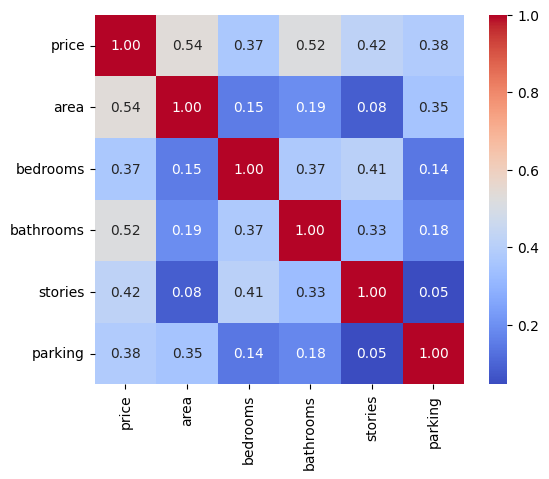

In [11]:
# Draw heatmap
sns.heatmap(numeric_col.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)

# Univariate Analysis

(array([ 61., 163., 139.,  89.,  46.,  25.,  13.,   4.,   1.,   4.]),
 array([ 1750000.,  2905000.,  4060000.,  5215000.,  6370000.,  7525000.,
         8680000.,  9835000., 10990000., 12145000., 13300000.]),
 <BarContainer object of 10 artists>)

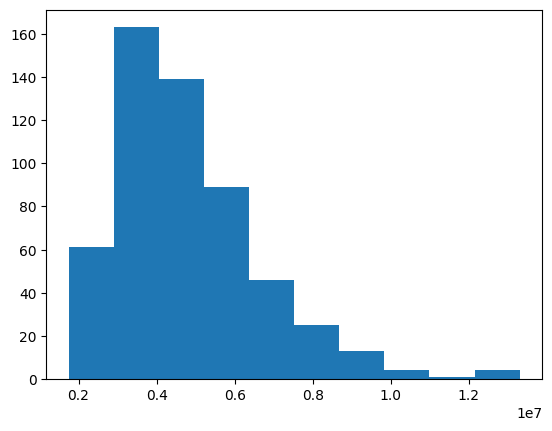

In [12]:
plt.hist(df['price'])

1 ) more price was of range 0.3 - 0.4 e7

<Axes: ylabel='price'>

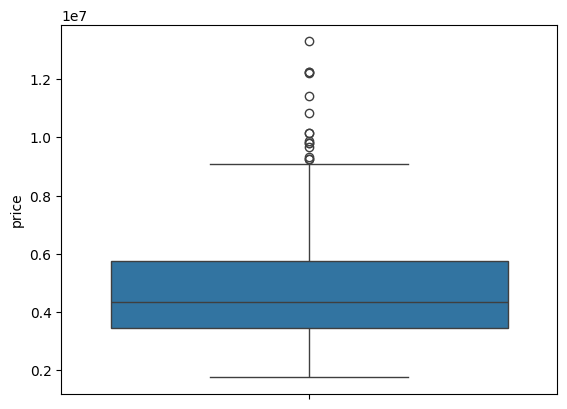

In [13]:
sns.boxplot(df['price'])

<Axes: ylabel='area'>

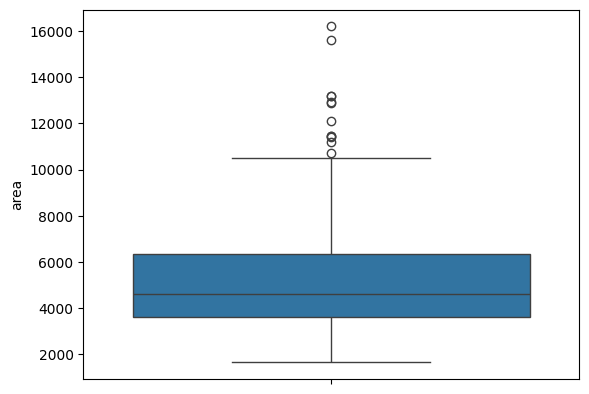

In [15]:
sns.boxplot(df['area'])

<Axes: ylabel='area_log'>

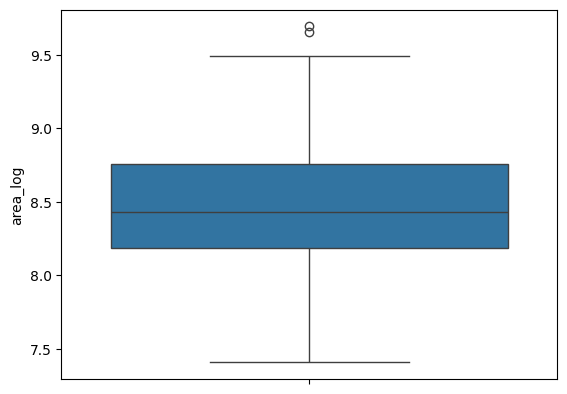

In [16]:
df['area_log'] = np.log1p(df['area'])
sns.boxplot(df['area_log'])

In [19]:
df['area_log'].skew()

np.float64(0.13374740415416703)

<Axes: ylabel='bathrooms'>

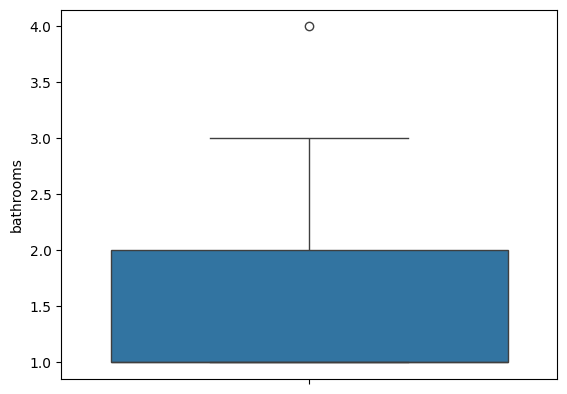

In [17]:
sns.boxplot(df['bathrooms'])

<Axes: ylabel='bedrooms'>

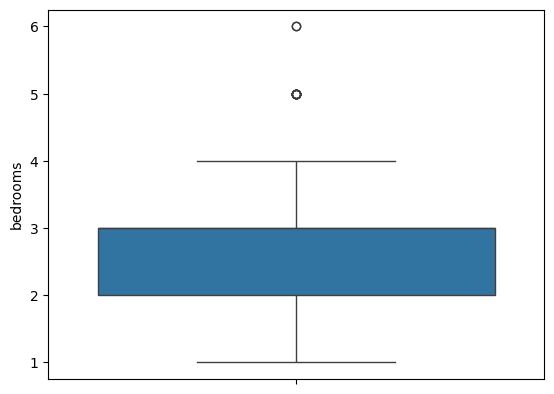

In [21]:
sns.boxplot(df['bedrooms'])

<Axes: ylabel='stories'>

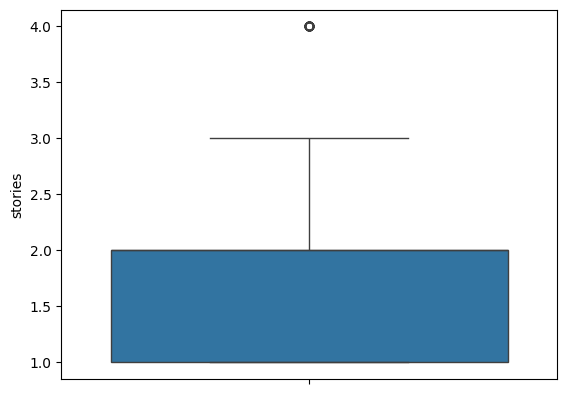

In [23]:
sns.boxplot(df['stories'])

<Axes: ylabel='parking'>

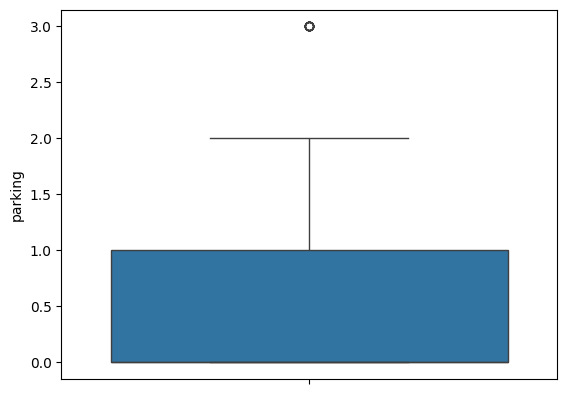

In [24]:
sns.boxplot(df['parking'])

Outliers are removed 

Encoding

In [32]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea','furnishingstatus']

for col in binary_cols:
    print(f"{col}: {df[col].value_counts()}")

mainroad: mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom: guestroom
no     448
yes     97
Name: count, dtype: int64
basement: basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating: hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning: airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea: prefarea
no     417
yes    128
Name: count, dtype: int64
furnishingstatus: furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [33]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [34]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            545 non-null    int64  
 1   area                             545 non-null    int64  
 2   bedrooms                         545 non-null    int64  
 3   bathrooms                        545 non-null    int64  
 4   stories                          545 non-null    int64  
 5   mainroad                         545 non-null    int64  
 6   guestroom                        545 non-null    int64  
 7   basement                         545 non-null    int64  
 8   hotwaterheating                  545 non-null    int64  
 9   airconditioning                  545 non-null    int64  
 10  parking                          545 non-null    int64  
 11  prefarea                         545 non-null    int64  
 12  area_log              

removing area

In [36]:
df.drop(columns=['area'],inplace=True)

In [37]:
df.head()

,price,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,area_log,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,4,2,3,1,0,0,0,1,2,1,8.912069,False,False
1,12250000,4,4,4,1,0,0,0,1,3,0,9.100637,False,False
2,12250000,3,2,2,1,0,1,0,0,2,1,9.206433,True,False
3,12215000,4,2,2,1,0,1,0,1,3,1,8.922792,False,False
4,11410000,4,1,2,1,1,1,0,1,2,0,8.912069,False,False


In [38]:
df.to_csv('cleaned_house_price.csv',index=False)